# Assignment 4
## Econ 8310 - Business Forecasting

This assignment will make use of the bayesian statistical models covered in Lessons 10 to 12. 

A/B Testing is a critical concept in data science, and for many companies one of the most relevant applications of data-driven decision-making. In order to improve product offerings, marketing campaigns, user interfaces, and many other user-facing interactions, scientists and engineers create experiments to determine the efficacy of proposed changes. Users are then randomly assigned to either the treatment or control group, and their behavior is recorded.
If the changes that the treatment group is exposed to can be measured to have a benefit in the metric of interest, then those changes are scaled up and rolled out to across all interactions.
Below is a short video detailing the A/B Testing process, in case you want to learn a bit more:
[https://youtu.be/DUNk4GPZ9bw](https://youtu.be/DUNk4GPZ9bw)

For this assignment, you will use an A/B test data set, which was pulled from the Kaggle website (https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing). I have added the data from the page into Codio for you. It can be found in the cookie_cats.csv file in the file tree. It can also be found at [https://github.com/dustywhite7/Econ8310/raw/master/AssignmentData/cookie_cats.csv](https://github.com/dustywhite7/Econ8310/raw/master/AssignmentData/cookie_cats.csv)

The variables are defined as follows:

| Variable Name  | Definition |
|----------------|----|
| userid         | A unique number that identifies each player  |
| version        | Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40) |
| sum_gamerounds | The number of game rounds played by the player during the first 14 days after install.  |
| retention1     | Did the player come back and play 1 day after installing?     |
| retention7     | Did the player come back and play 7 days after installing?    |               

### The questions

You will be asked to answer the following questions in a small quiz on Canvas:
1. What was the effect of moving the gate from level 30 to level 40 on 1-day retention rates?
2. What was the effect of moving the gate from level 30 to level 40 on 7-day retention rates?
3. What was the biggest challenge for you in completing this assignment?

You will also be asked to submit a URL to your forked GitHub repository containing your code used to answer these questions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

Matplotlib is building the font cache; this may take a moment.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
# Load the data
game_data = pd.read_csv('https://raw.githubusercontent.com/dustywhite7/Econ8310/master/AssignmentData/cookie_cats.csv')
len_data = len(game_data)

# Convert booleans to ints for easier analysis
game_data['retention_1'] = game_data['retention_1'].astype(int)
game_data['retention_7'] = game_data['retention_7'].astype(int)

# Split into the two test groups
g30 = game_data[game_data['version'] == 'gate_30']
g40 = game_data[game_data['version'] == 'gate_40']

print('Total number of records:', len_data)
print('Players in gate_30:', len(g30))
print('Players in gate_40:', len(g40))

Total number of records: 90189
Players in gate_30: 44700
Players in gate_40: 45489


In [5]:
# Quick summary of 1-day retention
g30_sum = g30['retention_1'].sum()
g40_sum = g40['retention_1'].sum()
g30_mean = g30['retention_1'].mean()
g40_mean = g40['retention_1'].mean()
pct_change = ((g40_mean - g30_mean) / g30_mean) * 100

print('=== 1-day retention ===')
print(f'gate_30: {g30_sum} retained out of {len(g30)} ({g30_mean:.2%})')
print(f'gate_40: {g40_sum} retained out of {len(g40)} ({g40_mean:.2%})')
print(f'Percent change moving gate_30 -> gate_40: {pct_change:.2f}%')

=== 1-day retention ===
gate_30: 20034 retained out of 44700 (44.82%)
gate_40: 20119 retained out of 45489 (44.23%)
Percent change moving gate_30 -> gate_40: -1.32%


In [17]:
## Bayesian A/B test for 1-day retention ##
# A = control (gate_30), B = treatment (gate_40)
with pm.Model() as model:
    # Uniform priors
    p_A = pm.Beta('p_A', 1, 1)
    p_B = pm.Beta('p_B', 1, 1)

    # Quantity of interest: difference between the two rates
    delta = pm.Deterministic('delta', p_A - p_B)

    # Bernoulli likelihoods on the observed retention values
    obs_A = pm.Bernoulli('obs_A', p_A, observed=g30['retention_1'])
    obs_B = pm.Bernoulli('obs_B', p_B, observed=g40['retention_1'])

    step = pm.Metropolis()
    trace = pm.sample(1000, step=step, chains=2, progressbar=False)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [p_A]
>Metropolis: [p_B]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 662 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [9]:
p_A_samples = trace.posterior['p_A'].values.flatten()
p_B_samples = trace.posterior['p_B'].values.flatten()
delta_samples = trace.posterior['delta'].values.flatten()

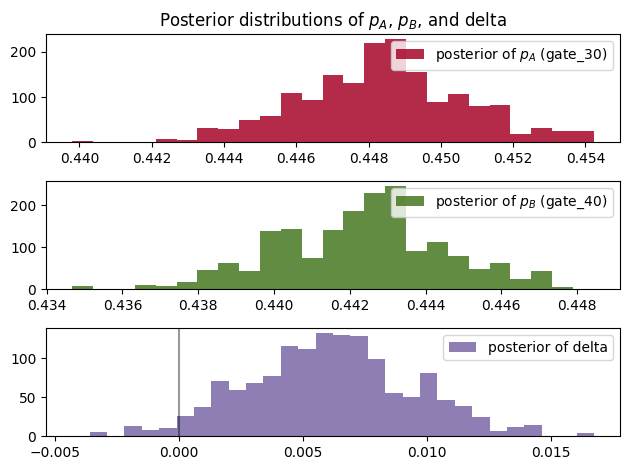

In [10]:
# Plot posteriors of p_A, p_B, and delta
plt.subplot(311)
plt.hist(p_A_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label='posterior of $p_A$ (gate_30)', color='#A60628', density=True)
plt.legend(loc='upper right')
plt.title('Posterior distributions of $p_A$, $p_B$, and delta')

plt.subplot(312)
plt.hist(p_B_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label='posterior of $p_B$ (gate_40)', color='#467821', density=True)
plt.legend(loc='upper right')

plt.subplot(313)
plt.hist(delta_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label='posterior of delta', color='#7A68A6', density=True)
plt.axvline(0, color='black', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
# Probability the control (gate_30) is better/worse than the treatment (gate_40)
print(f'P(gate_30 worse than gate_40):  {np.mean(delta_samples < 0):.3f}')
print(f'P(gate_30 better than gate_40): {np.mean(delta_samples > 0):.3f}')

P(gate_30 worse than gate_40):  0.028
P(gate_30 better than gate_40): 0.973


In [12]:
# Quick descriptive summary of 7-day retention
g30_sum7 = g30['retention_7'].sum()
g40_sum7 = g40['retention_7'].sum()
g30_mean7 = g30['retention_7'].mean()
g40_mean7 = g40['retention_7'].mean()
pct_change7 = ((g40_mean7 - g30_mean7) / g30_mean7) * 100

print('=== 7-day retention ===')
print(f'gate_30: {g30_sum7} retained out of {len(g30)} ({g30_mean7:.2%})')
print(f'gate_40: {g40_sum7} retained out of {len(g40)} ({g40_mean7:.2%})')
print(f'Percent change moving gate_30 -> gate_40: {pct_change7:.2f}%')

=== 7-day retention ===
gate_30: 8502 retained out of 44700 (19.02%)
gate_40: 8279 retained out of 45489 (18.20%)
Percent change moving gate_30 -> gate_40: -4.31%


In [13]:
### Bayesian A/B test for 7-day retention ###
with pm.Model() as model:
    p_A = pm.Beta('p_A', 1, 1)
    p_B = pm.Beta('p_B', 1, 1)
    delta = pm.Deterministic('delta', p_A - p_B)

    obs_A = pm.Bernoulli('obs_A', p_A, observed=g30['retention_7'])
    obs_B = pm.Bernoulli('obs_B', p_B, observed=g40['retention_7'])

    step = pm.Metropolis()
    trace = pm.sample(1000, step=step, chains=2, progressbar=False)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [p_A]
>Metropolis: [p_B]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 648 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [14]:
p_A_samples = trace.posterior['p_A'].values.flatten()
p_B_samples = trace.posterior['p_B'].values.flatten()
delta_samples = trace.posterior['delta'].values.flatten()

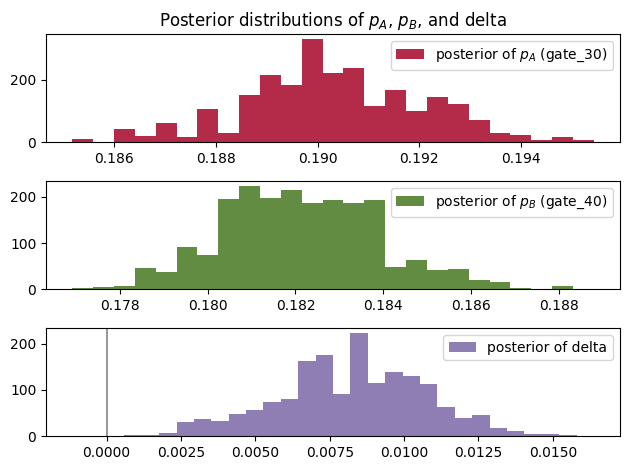

In [15]:
plt.subplot(311)
plt.hist(p_A_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label='posterior of $p_A$ (gate_30)', color='#A60628', density=True)
plt.legend(loc='upper right')
plt.title('Posterior distributions of $p_A$, $p_B$, and delta')

plt.subplot(312)
plt.hist(p_B_samples, histtype='stepfilled', bins=25, alpha=0.85,
         label='posterior of $p_B$ (gate_40)', color='#467821', density=True)
plt.legend(loc='upper right')

plt.subplot(313)
plt.hist(delta_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label='posterior of delta', color='#7A68A6', density=True)
plt.axvline(0, color='black', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
print(f'P(gate_30 worse than gate_40):  {np.mean(delta_samples < 0):.3f}')
print(f'P(gate_30 better than gate_40): {np.mean(delta_samples > 0):.3f}')

P(gate_30 worse than gate_40):  0.001
P(gate_30 better than gate_40): 1.000
